<div align="center">

<h1>TP1 - Projeto de Bloco: Análise e Segurança de Agentes de IA</h1>

</div>

##### Professor: Tiago Xavier;
###### Estudantes - E-mails: 
###### Caio Ribeiro Pereira - caio.rpereira@al.infnet.edu.br;
###### Paulo Henrique de Paula Dias - paulo.dias@al.infnet.edu.br;
###### Pedro Marchiori de Araújo - pedro.maraujo@al.infnet.edu.br.

### Instruções



**Dataset**

O dataset para o trabalho é 'Customer Support Ticket Dataset' disponível no kaggle no link:

DatasetLink: https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset/data



#### **Tarefas Iniciais**
##### Instruções realizadas nesse arquivo

1. Leia toda a documentação disponível para o 'Customer Support Ticket Dataset' e documente tecnicamente o seguinte:
- Fonte (origem do dataset)
- Principais características
- Motivo de escolha do dataset.
2. Realize a EDA inicial no dataset. O EDA deve ser implementado como visto em aula e deve conter os seguintes passos:
- Compreensão do problema e do dataset
- Inspeção inicial
- Verificação da qualidade dos dados
- Limpeza e preparação dos dados
- Análise Univariada
3. A partir da Análise Univariada e o desenvolvimento de histogramas e gráficos para visualização das distribuições das principais variáveis, escreva pelo menos 3 hipóteses sobre as "intenções" dos usuários a partir dos padrões observados.


### **Tarefa 1**
Leia toda a documentação disponível para o 'Customer Support Ticket Dataset' e documente tecnicamente o seguinte:
* Fonte (origem do dataset)
* Principais características
* Motivo de escolha do dataset.

O *dataset* "*Customer Support Ticket Dataset*" ([Link](https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset/data)), trata-se de uma base de dados pública disponível na plataforma Kaggle. Licenciado sob a **CC0: Public Domain** conforme informado na página oficial do dataset. Essa licença permite a utilização, modificação e redistribuição do conteúdo sem necessidade de solicitar autorização adicional ao autor. O *dataset* é composto por tickets de suporte ao cliente para problemas relacionados a diversos produtos tecnológicos, como:
* Problemas com Hardware;
* *Bugs* em Software;
* Problemas de Conectividade;
* Problemas de Acesso a Plataformas;
* Perda de Dados;
* Entre outros serviços.

A base de dados é composta pelas seguintes colunas:

- Ticket ID: Identificador único.
- Customer Name: Nome do cliente.
- Customer Email: Email do cliente (Alguns estão dispostos como - @example.com intencionalmente para privacidade).
- Customer Age: Idade do cliente.
- Customer Gender: Gênero do cliente.
- Product Purchased: O produto comprado pelo cliente.
- Date of Purchase: Data de compra do produto.
- Ticket Type: Classificação do ticket (Exemplo: *technical issue*, *billing inquiry*, *product inquiry*).
- Ticket Subject: O tópico/contexto do ticket.
- Ticket Description: Descriçaõ do motivo da abertura do ticket.
- Ticket Status: Status do ticket (Exemplo: *open*, *closed*, *pending customer response*).
- Resolution: A solução dada para tickets fechados.
- Ticket Priority: Nível de prioridade dado ao ticket (Exemplo: *low*, *medium*, *high*, *critical*).
- Ticket Channel: O canal de captura do ticket (Exemplo: *email*, *phone*, *chat*, *social media*).
- First Response Time: O tempo da primeira resposta ao cliente.
- Time to Resolution: Tempo de resolução completa do ticket.
- Customer Satisfaction Rating: Nível de satisfação do cliente entre 1 e 5.

Este *dataset* foi escolhido como base devido a sua variabilidade e complexidade, permitindo análise abrangente de dados de suporte ao cliente. Além disso, a variedade de elementos disponíveis permite a exploração de diferentes aspectos do atendimento ao cliente, como tempo de resposta, prioridade de tickets e satisfação do cliente. Esses elementos são essenciais para a construção de um sistema de IA que possa não apenas classificar tickets, mas também prever tendências e melhorar a eficiência do atendimento.

### **Tarefa 2**

Realize a EDA inicial no dataset. O EDA deve ser implementado como visto em aula e deve conter os seguintes passos:
- Compreensão do problema e do dataset
- Inspeção inicial
- Verificação da qualidade dos dados
- Limpeza e preparação dos dados
- Análise Univariada

#### Importando bibliotecas e o dataset

In [45]:
import string
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import numpy as np
from scipy.stats import chi2_contingency


cs_df = pd.read_csv("../data/customer_support_tickets.csv")
cs_df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0


*Dataset* é composto de 8469 linhas e 17 colunas, contendo informações sobre tickets de suporte ao cliente em relação à diversos produtos tecnológicos. Existem vários perguntas que podem ser endereçadas através desta base, como abaixo:

- Qual faixa etária apresenta maior dificuldade em utilizar os produtos?
- Qual gênero apresenta maior dificuldade em utilizar os produtos?
- Qual produto apresenta maior dificuldade em ser utilizado?
- Qual canal de atendimento apresenta maior facilidade/dificuldade de ser usado?
- Qual tipo de ticket apresenta maior dificuldade em ser resolvido?
- Qual prioridade de ticket apresenta maior dificuldade em ser resolvido?
- Qual fator de relevância faz um ticket não ser fechado
- O tempo de resposta de acordo com qual problema é mais rápido/demorado de ser resolvido?
- Qual a relação entre nível de satisfação e tempo e resolução (ou outra variável)?
- Entre outras possíveis perguntas.

##  Inspeção inicial

In [46]:
cs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [47]:
cs_df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [48]:
cs_df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [49]:
cs_df.describe(include="object")

,Customer Name,Customer Email,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution
count,8469,8469,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769
unique,8028,8320,3,42,730,5,16,8077,3,2769,4,4,5470,2728
top,Michael Garcia,asmith@example.com,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,Case maybe show recently my computer follow.,Medium,Email,2023-06-01 15:21:42,2023-06-01 17:14:42
freq,5,4,2896,240,24,1752,576,25,2881,1,2192,2143,3,3


In [50]:
colunas_categoricas = cs_df.select_dtypes(include="object").columns

for coluna in colunas_categoricas:
    n_unicos = cs_df[coluna].nunique()
    print(f"{coluna}: {n_unicos} valores únicos")

Customer Name: 8028 valores únicos
Customer Email: 8320 valores únicos
Customer Gender: 3 valores únicos
Product Purchased: 42 valores únicos
Date of Purchase: 730 valores únicos
Ticket Type: 5 valores únicos
Ticket Subject: 16 valores únicos
Ticket Description: 8077 valores únicos
Ticket Status: 3 valores únicos
Resolution: 2769 valores únicos
Ticket Priority: 4 valores únicos
Ticket Channel: 4 valores únicos
First Response Time: 5470 valores únicos
Time to Resolution: 2728 valores únicos


A inspeção inicial confirma que o *dataset* possui 8469 linhas e 17 colunas, sem nenhuma coluna totalmente vazia. As colunas `Customer Age` e `Ticket ID` são numéricas (inteiras), `Customer Satisfaction Rating` é numérica (float, pois possui valores ausentes), e as demais 14 colunas são categóricas/texto (tipo `object`), incluindo as colunas de data (`Date of Purchase`, `First Response Time`, `Time to Resolution`), que estão armazenadas como texto e precisarão ser convertidas para o tipo *datetime* na etapa de limpeza.

Colunas como `Customer Name`, `Customer Email` e `Ticket Description` possuem alta cardinalidade (quase um valor único por linha), como esperado para identificadores e textos livres. Já colunas como `Ticket Type`, `Ticket Status`, `Ticket Priority` e `Ticket Channel` possuem poucas categorias, sendo boas candidatas para a Análise Univariada.

## Verificação da qualidade dos dados

In [51]:
valores_nulos = cs_df.isnull().sum()
percentual_nulos = (cs_df.isnull().mean() * 100).round(2)

qualidade_df = pd.DataFrame({
    "valores_nulos": valores_nulos,
    "percentual_nulos (%)": percentual_nulos
}).sort_values(by="valores_nulos", ascending=False)

qualidade_df

,valores_nulos,percentual_nulos (%)
Customer Satisfaction Rating,5700,67.30
Resolution,5700,67.30
Time to Resolution,5700,67.30
First Response Time,2819,33.29
Ticket ID,0,0.00
Customer Name,0,0.00
Customer Email,0,0.00
Customer Age,0,0.00
Customer Gender,0,0.00
Ticket Subject,0,0.00


In [52]:
linhas_duplicadas = cs_df.duplicated().sum()
tickets_duplicados = cs_df["Ticket ID"].duplicated().sum()

print(f"Linhas totalmente duplicadas: {linhas_duplicadas}")
print(f"Ticket IDs duplicados: {tickets_duplicados}")

Linhas totalmente duplicadas: 0
Ticket IDs duplicados: 0


In [53]:
print("Faixa de Customer Age:", cs_df["Customer Age"].min(), "-", cs_df["Customer Age"].max())
print("Valores únicos de Customer Satisfaction Rating:", sorted(cs_df["Customer Satisfaction Rating"].dropna().unique()))
print("Valores únicos de Ticket Status:", cs_df["Ticket Status"].unique())
print("Valores únicos de Ticket Priority:", cs_df["Ticket Priority"].unique())
print("Valores únicos de Ticket Channel:", cs_df["Ticket Channel"].unique())
print("Valores únicos de Customer Gender:", cs_df["Customer Gender"].unique())

Faixa de Customer Age: 18 - 70
Valores únicos de Customer Satisfaction Rating: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
Valores únicos de Ticket Status: ['Pending Customer Response' 'Closed' 'Open']
Valores únicos de Ticket Priority: ['Critical' 'Low' 'High' 'Medium']
Valores únicos de Ticket Channel: ['Social media' 'Chat' 'Email' 'Phone']
Valores únicos de Customer Gender: ['Other' 'Female' 'Male']


In [54]:
emails_invalidos = ~cs_df["Customer Email"].str.contains(r"^[^@]+@[^@]+\.[^@]+$", regex=True, na=False)
print(f"E-mails com formato inválido: {emails_invalidos.sum()}")
print(f"Domínios de e-mail únicos (amostra): {cs_df['Customer Email'].str.split('@').str[1].value_counts().head()}")

E-mails com formato inválido: 0
Domínios de e-mail únicos (amostra): Customer Email
example.com    2904
example.org    2796
example.net    2769
Name: count, dtype: int64


In [55]:
datas_temp = cs_df.copy()
for coluna in ["First Response Time", "Time to Resolution"]:
    datas_temp[coluna] = pd.to_datetime(datas_temp[coluna], errors="coerce")

diferenca_horas = (datas_temp["Time to Resolution"] - datas_temp["First Response Time"]).dt.total_seconds() / 3600
inconsistencias_cronologicas = (diferenca_horas < 0).sum()

print(f"Datas únicas em First Response Time: {datas_temp['First Response Time'].dt.date.nunique()}")
print(f"Datas únicas em Time to Resolution: {datas_temp['Time to Resolution'].dt.date.nunique()}")
print(f"Tickets com Time to Resolution anterior a First Response Time: {inconsistencias_cronologicas}")

Datas únicas em First Response Time: 3
Datas únicas em Time to Resolution: 3
Tickets com Time to Resolution anterior a First Response Time: 1365


A verificação de qualidade revela os seguintes pontos:

- **Valores ausentes concentrados em três colunas**: `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` possuem uma quantidade relevante de nulos. Isso não é um erro de coleta, mas sim um reflexo do próprio processo de negócio: tickets que ainda estão `Open` ou `Pending Customer Response` naturalmente não possuem resolução, tempo de resolução nem avaliação de satisfação, pois esses campos só são preenchidos quando o ticket é `Closed`. `First Response Time` também possui nulos, referentes a tickets que ainda não tiveram uma primeira resposta.
- **Não há linhas totalmente duplicadas** nem `Ticket ID` duplicado, ou seja, cada linha representa um ticket único.
- **Os domínios de e-mail** (`Customer Email`) são majoritariamente `@example.com`/`@example.org`/`@example.net`, confirmando o que a documentação do *dataset* já informava: os e-mails foram anonimizados/gerados sinteticamente por questões de privacidade, e não representam e-mails reais de clientes.
- **As colunas categóricas de controle** (`Ticket Status`, `Ticket Priority`, `Ticket Channel`, `Customer Gender`) possuem apenas os valores esperados, sem inconsistências de digitação (ex: variações de caixa alta/baixa ou espaços extras).
- **`Customer Age`** está dentro de uma faixa plausível (sem idades negativas ou absurdamente altas) e **`Customer Satisfaction Rating`** está corretamente restrito à escala de 1 a 5.
- **Inconsistência cronológica entre `First Response Time` e `Time to Resolution`**: ao calcular a diferença entre essas duas colunas, 1365 tickets apresentam `Time to Resolution` *anterior* a `First Response Time` (diferenças negativas de até -23h). Investigando a causa, ambas as colunas possuem apenas 3 datas únicas (todas em torno de 01/06/2023), o que indica que esses horários foram **gerados sinteticamente de forma aleatória**, sem relação causal real com o ciclo de vida do ticket (não é uma inconsistência de digitação, e sim uma limitação estrutural do *dataset* sintético). Isso será tratado na etapa de limpeza.

## Limpeza e preparação dos dados

In [56]:
cs_df_limpo = cs_df.copy()

colunas_data = ["Date of Purchase", "First Response Time", "Time to Resolution"]
for coluna in colunas_data:
    cs_df_limpo[coluna] = pd.to_datetime(cs_df_limpo[coluna], errors="coerce")

cs_df_limpo[colunas_data].dtypes

Date of Purchase       datetime64[ns]
First Response Time    datetime64[ns]
Time to Resolution     datetime64[ns]
dtype: object

In [57]:
colunas_texto = cs_df_limpo.select_dtypes(include="object").columns
for coluna in colunas_texto:
    cs_df_limpo[coluna] = cs_df_limpo[coluna].str.strip()

In [58]:
cs_df_limpo["Ticket Resolvido"] = cs_df_limpo["Ticket Status"].eq("Closed")

cs_df_limpo["Tempo de Resolucao (horas)"] = (
    (cs_df_limpo["Time to Resolution"] - cs_df_limpo["First Response Time"]).dt.total_seconds() / 3600
)

# First Response Time e Time to Resolution são gerados sem relação cronológica real
# (ver Verificação da qualidade dos dados), então durações negativas são inválidas
# e marcadas como ausentes em vez de mantidas como número negativo sem sentido.
duracoes_invalidas = cs_df_limpo["Tempo de Resolucao (horas)"] < 0
print(f"Durações negativas invalidadas: {duracoes_invalidas.sum()}")
cs_df_limpo.loc[duracoes_invalidas, "Tempo de Resolucao (horas)"] = pd.NA

cs_df_limpo["Tamanho da Descricao"] = cs_df_limpo["Ticket Description"].str.len()

cs_df_limpo[["Ticket Resolvido", "Tempo de Resolucao (horas)", "Tamanho da Descricao"]].describe(include="all")

Durações negativas invalidadas: 1365


,Ticket Resolvido,Tempo de Resolucao (horas),Tamanho da Descricao
count,8469,1404.000000,8469.000000
unique,2,NaN,NaN
top,False,NaN,NaN
freq,5700,NaN,NaN
mean,NaN,7.577932,289.821939
std,NaN,5.596637,43.593954
min,NaN,0.000000,151.000000
25%,NaN,3.000000,273.000000
50%,NaN,6.341667,298.000000
75%,NaN,11.354167,318.000000


In [59]:
cs_df_limpo = cs_df_limpo.drop_duplicates()
print("Shape após limpeza:", cs_df_limpo.shape)
cs_df_limpo.head()

Shape após limpeza: (8469, 20)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Ticket Resolvido,Tempo de Resolucao (horas),Tamanho da Descricao
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN,False,NaN,284
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN,False,NaN,282
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,True,6.850000,275
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,True,NaN,262
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,True,19.683333,333


Nesta etapa, o *dataset* original foi preservado em `cs_df` e todas as transformações foram aplicadas em uma cópia, `cs_df_limpo`, com as seguintes ações:

1. **Conversão de tipos**: as colunas `Date of Purchase`, `First Response Time` e `Time to Resolution` foram convertidas de texto (`object`) para `datetime`, permitindo cálculos temporais.
2. **Padronização de texto**: espaços em branco extras nas colunas categóricas/texto foram removidos com `str.strip()`.
3. **Tratamento dos valores ausentes**: optou-se por não remover nem imputar artificialmente os valores nulos de `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating`, pois como identificado na verificação de qualidade, esses nulos são estruturais (refletem tickets ainda não fechados) e não erros de coleta. Removê-los enviesaria a análise ao descartar todos os tickets em aberto.
4. **Engenharia de atributos**: foram criadas três colunas auxiliares que serão úteis na Análise Univariada e nas próximas etapas do projeto:
   - `Ticket Resolvido`: *flag* booleana indicando se o ticket está `Closed`.
   - `Tempo de Resolução (horas)`: diferença, em horas, entre a primeira resposta e a resolução do ticket (fica `NaN` quando o ticket não foi resolvido). Como identificado na verificação de qualidade, `First Response Time` e `Time to Resolution` não têm relação cronológica real entre si (são gerados sinteticamente), o que produzia durações negativas sem sentido; essas 1365 durações negativas foram marcadas como `NaN` em vez de mantidas como número negativo.
   - `Tamanho da Descrição`: número de caracteres do campo `Ticket Description`.
5. **Remoção de duplicatas**: aplicado `drop_duplicates()` por segurança, embora a verificação de qualidade já tenha confirmado a ausência de linhas duplicadas.

## Análise Univariada

### Variáveis Numérica


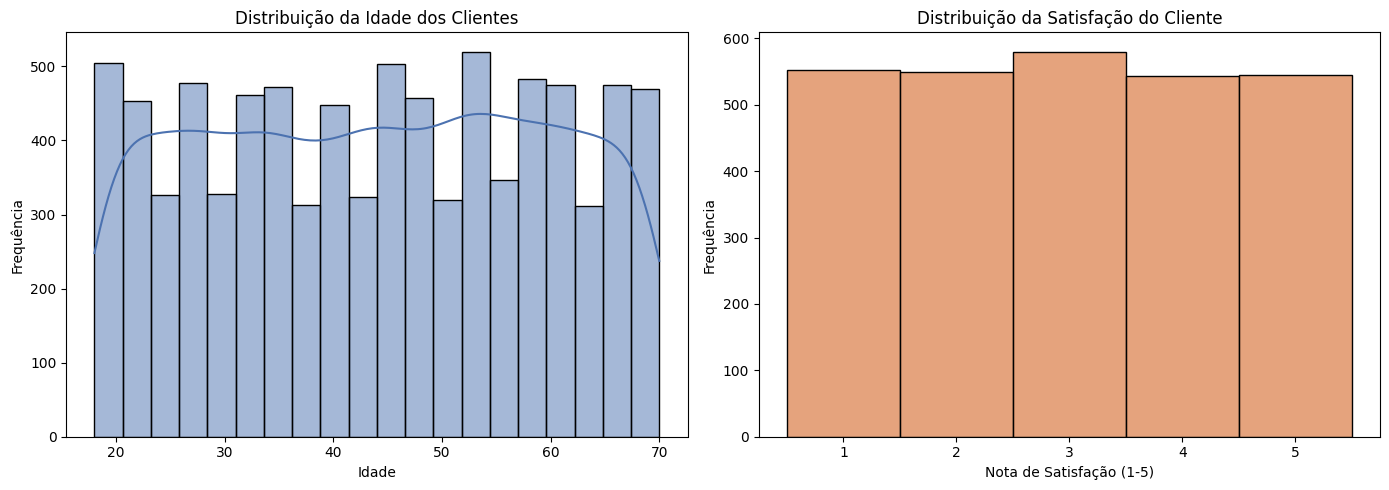

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(cs_df_limpo["Customer Age"], bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuição da Idade dos Clientes")
axes[0].set_xlabel("Idade")
axes[0].set_ylabel("Frequência")

sns.histplot(cs_df_limpo["Customer Satisfaction Rating"].dropna(), bins=5, discrete=True, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribuição da Satisfação do Cliente")
axes[1].set_xlabel("Nota de Satisfação (1-5)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

In [61]:
cs_df_limpo[["Customer Age", "Customer Satisfaction Rating", "Tempo de Resolucao (horas)"]].describe()

,Customer Age,Customer Satisfaction Rating,Tempo de Resolucao (horas)
count,8469.000000,2769.000000,1404.000000
mean,44.026804,2.991333,7.577932
std,15.296112,1.407016,5.596637
min,18.000000,1.000000,0.000000
25%,31.000000,2.000000,3.000000
50%,44.000000,3.000000,6.341667
75%,57.000000,4.000000,11.354167
max,70.000000,5.000000,23.466667


### Variáveis categóricas


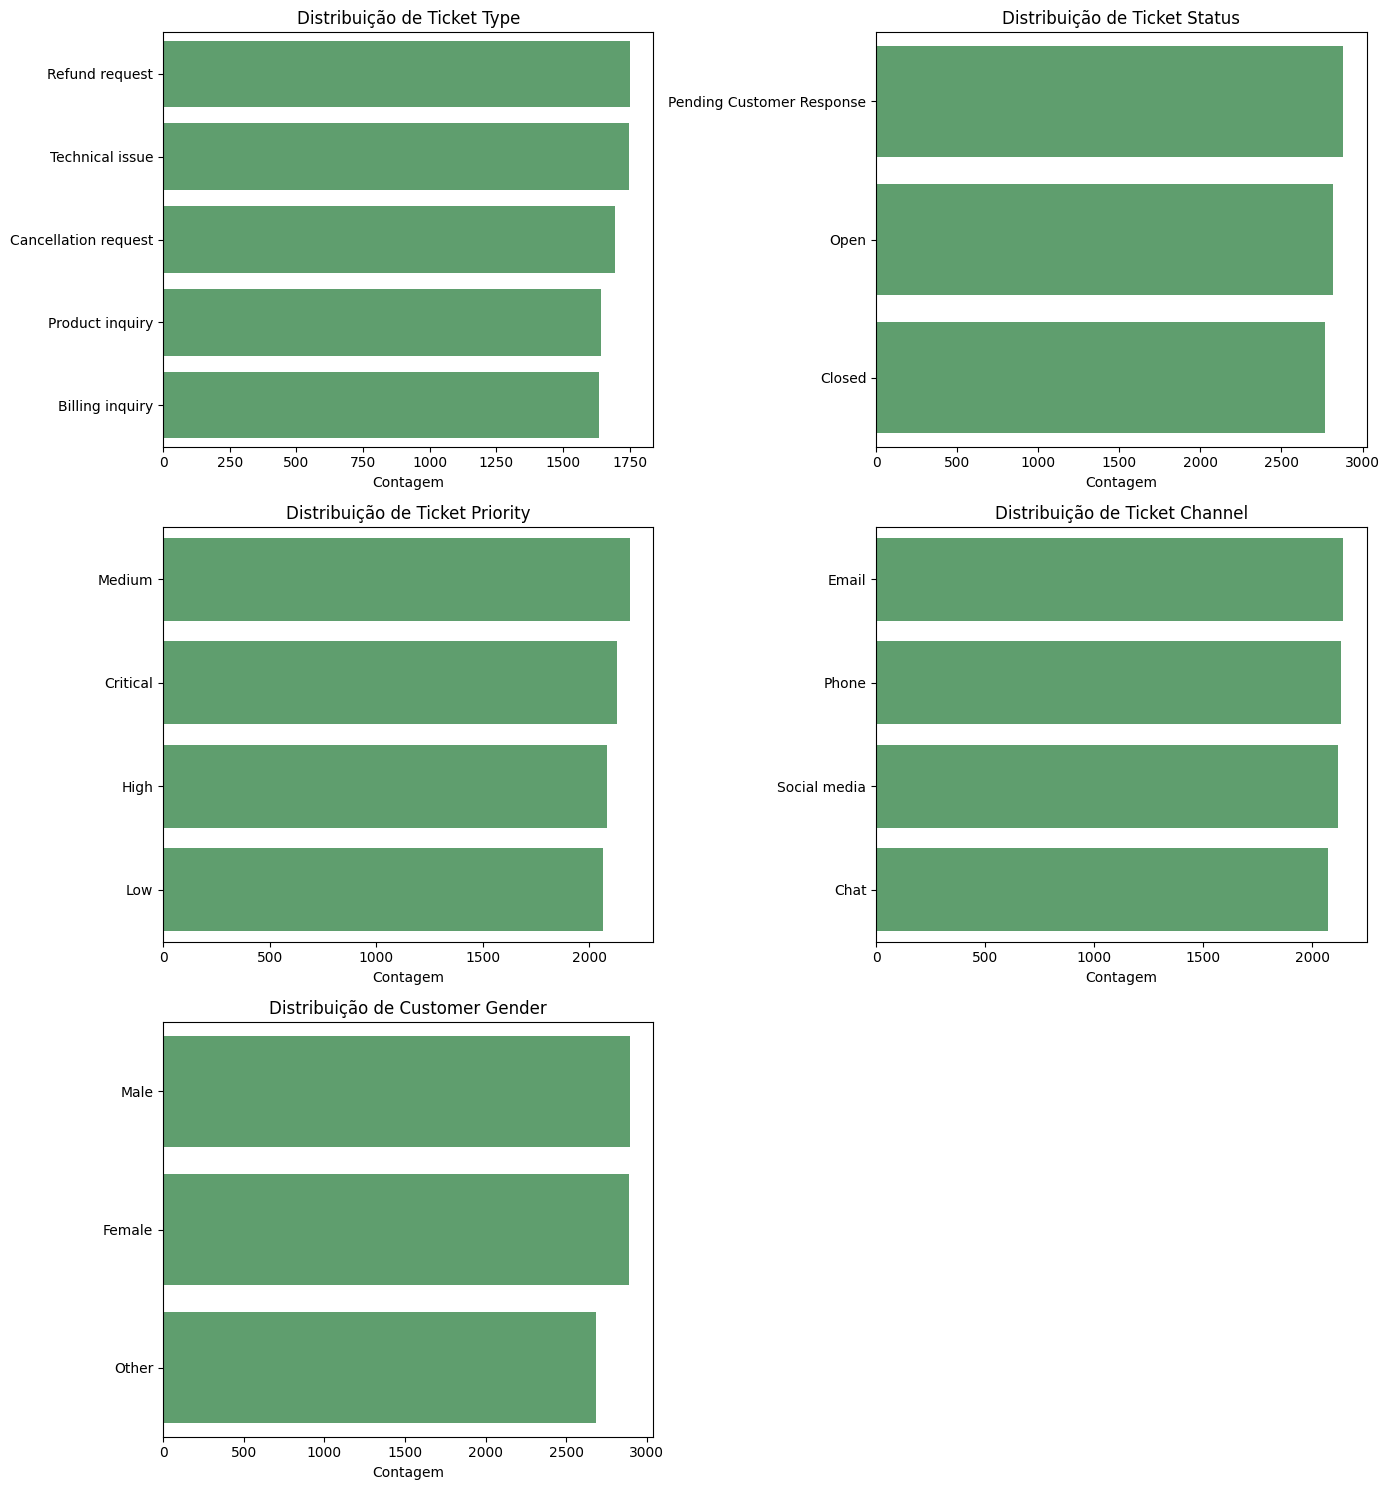

In [62]:
colunas_categoricas_analise = [
    "Ticket Type",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel",
    "Customer Gender",
]

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for ax, coluna in zip(axes, colunas_categoricas_analise):
    ordem = cs_df_limpo[coluna].value_counts().index
    sns.countplot(data=cs_df_limpo, y=coluna, order=ordem, ax=ax, color="#55A868")
    ax.set_title(f"Distribuição de {coluna}")
    ax.set_xlabel("Contagem")
    ax.set_ylabel("")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

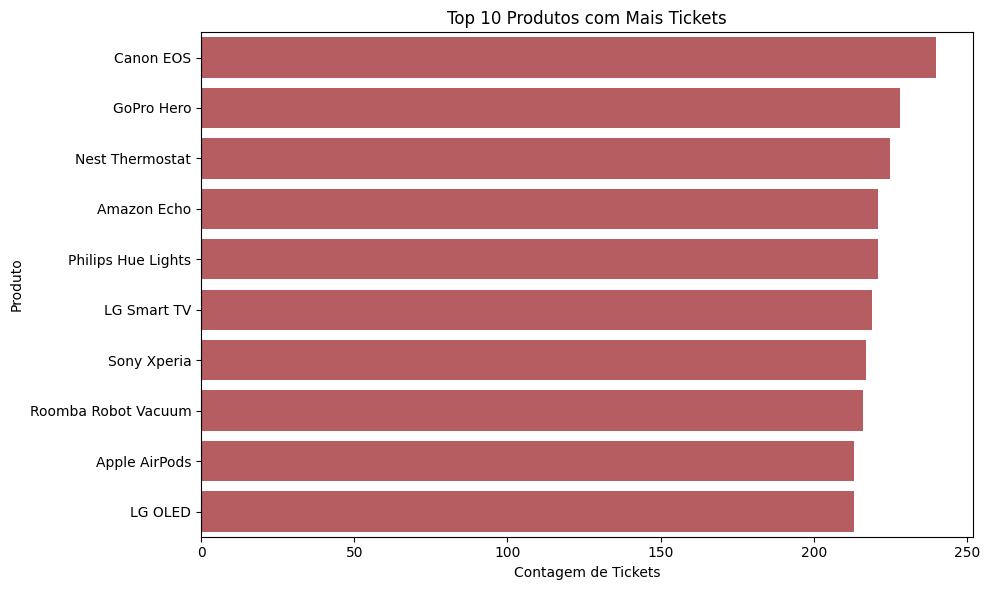

In [63]:
top_produtos = cs_df_limpo["Product Purchased"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_produtos.values, y=top_produtos.index, color="#C44E52")
plt.title("Top 10 Produtos com Mais Tickets")
plt.xlabel("Contagem de Tickets")
plt.ylabel("Produto")
plt.tight_layout()
plt.show()

In [64]:
for coluna in colunas_categoricas_analise:
    print(f"--- {coluna} ---")
    print(cs_df_limpo[coluna].value_counts(normalize=True).round(3) * 100)
    print()

--- Ticket Type ---
Ticket Type
Refund request          20.7
Technical issue         20.6
Cancellation request    20.0
Product inquiry         19.4
Billing inquiry         19.3
Name: proportion, dtype: float64

--- Ticket Status ---
Ticket Status
Pending Customer Response    34.0
Open                         33.3
Closed                       32.7
Name: proportion, dtype: float64

--- Ticket Priority ---
Ticket Priority
Medium      25.9
Critical    25.1
High        24.6
Low         24.4
Name: proportion, dtype: float64

--- Ticket Channel ---
Ticket Channel
Email           25.3
Phone           25.2
Social media    25.0
Chat            24.5
Name: proportion, dtype: float64

--- Customer Gender ---
Customer Gender
Male      34.2
Female    34.1
Other     31.7
Name: proportion, dtype: float64



A Análise Univariada mostra os seguintes padrões:

- **`Customer Age`** apresenta distribuição aproximadamente uniforme entre 18 e 70 anos, sem concentração forte em nenhuma faixa etária específica, sugerindo que o produto/serviço atende um público amplo e heterogêneo em idade.
- **`Customer Satisfaction Rating`** está distribuída de forma praticamente uniforme entre as notas 1 a 5, sem uma tendência clara de satisfação ou insatisfação predominante entre os tickets fechados.
- **`Ticket Type`** está bem distribuído entre as categorias (*Technical issue*, *Billing inquiry*, *Cancellation request*, *Product inquiry*, *Refund request*), sem um tipo de problema claramente dominante.
- **`Ticket Status`** mostra proporção relevante de tickets `Closed` frente a `Open`/`Pending Customer Response`, reforçando a explicação anterior sobre os valores ausentes estruturais.
- **`Ticket Priority`** também é razoavelmente equilibrada entre `Low`, `Medium`, `High` e `Critical`.
- **`Ticket Channel`** mostra os quatro canais (*Email*, *Phone*, *Chat*, *Social media*) com volumes semelhantes entre si.
- **`Customer Gender`** possui três categorias (*Male*, *Female*, *Other*) com contagens próximas.
- Entre os produtos, alguns aparelhos/eletrônicos concentram mais tickets do que outros, indicando possíveis produtos com maior taxa de problemas reportados.

Essas distribuições relativamente equilibradas entre as variáveis categóricas são um indício de que o *dataset* foi gerado/balanceado artificialmente, o que é coerente com os e-mails sintéticos identificados na verificação de qualidade.

### **Tarefa 3**

A partir da Análise Univariada e o desenvolvimento de histogramas e gráficos para visualização das distribuições das principais variáveis, escreva pelo menos 3 hipóteses sobre as "intenções" dos usuários a partir dos padrões observados.

#### Hipótese 1: Intenção de resolução técnica e de dúvidas de produto concentrada em produtos com maior complexidade de uso

- **Padrão Observado:** A distribuição de chamados por produto revela que determinados eletrônicos de consumo e dispositivos inteligentes de casa (como Canon EOS com ~240 tickets, GoPro Hero com ~228 tickets, Nest Thermostat com ~225 tickets, Philips Hue Lights com ~220 e Amazon Echo com ~220) concentram o maior volume de tickets de suporte no dataset.
- **Hipótese de Intenção:** Os usuários desses produtos específicos possuem, predominantemente, a intenção de resolver problemas de configuração inicial, pareamento de rede ou dificuldades operacionais, dispositivos que exigem maior configuração com ecossistemas digitais ou configurações manuais complexas geram uma necessidade maior de auxílio do agente de suporte do que produtos com utilização mais simples.


#### Hipótese 2: Comportamento de cancelamento e reembolso independente do perfil demográfico do cliente

- **Padrão Observado:** As intenções de reembolso (Refund request, com 20,7%) e de cancelamento (Cancellation request, com 20,0%) somam mais de 40% de todos os chamados no sistema. A variável de idade (Customer Age) apresenta uma distribuição aproximadamente uniforme entre os 18 e 70 anos, sem aparente correlação significativa com nenhuma faixa etária
- **Hipótese de Intenção:** A intenção de desistir de um serviço ou exigir o estorno de um valor aparentemente não está correlacionada a fatores geracionais (como jovens sendo mais intolerantes ou idosos tendo mais dificuldade), mas a possíveis gargalos que afetam a experiência dos usuários de forma homogênea. Independentemente da idade, falhas no produto geram a mesma resposta comportamental de solicitação de cancelamento ou recuperação do dinheiro investido.


#### Hipótese 3: Grande parte das intenções dos usuários exige continuidade do atendimento

- **Padrão Observado:** Na distribuição de Ticket Status, apenas 32,7% dos tickets estão fechados, enquanto 33,3% permanecem abertos e 34,0% estão aguardando resposta do cliente. Dessa forma, 67,3% dos tickets ainda não estão concluídos.
- **Hipótese de Intenção:** Muitas das intenções apresentadas pelos usuários não são resolvidas em uma única interação e necessitam de continuidade no processo de atendimento. Isso pode envolver solicitações de informações adicionais ao cliente, investigação de problemas técnicos ou etapas adicionais para concluir cancelamentos, reembolsos e outras solicitações.

### **Tarefa 4**

Configure um projeto FastAPI com estrutura modular e que seja executável com 'uvicorn main:app --reload'. O código-fonte deve conter pelo menos:
- Arquivo 'main': ponto de entrada da aplicação FastAPI
- Diretório 'routes': contém a definição das rotas/endpoints da API
- Diretório 'models': contém os modelos Pydantic utilizados para validar os dados de entrada e saída da API.
- Diretório 'security': contém as funcionalidades relacionadas à segurança e autenticação, como geração e validação de tokens JWT e configuração do 'OAuth2PasswordBearer'.

Item 4 disponível no link abaixo:

Github: https://github.com/pmarchiori/caio_guilherme_paulo_pedro/blob/main/fastapi/main.py

### **Tarefa 5**

Implemente pelo menos 3 rotas: 'GET /health', 'POST /auth/token' e 'POST /predict'. A seguir está o objetivo de cada rota:
* 'GET /health': verifica se a API está ativa e funcionando corretamente.
* 'POST /auth/token': autentica o usuário e retorna um token JWT para acesso às rotas protegidas.
* 'POST /predict': não implementa o modelo de ML ainda. Esta rota recebe um texto e retorna uma intenção pré-determinada que simula a saída de um modelo que será implementado posteriormente.

Item 5 disponível no link abaixo:

Github: https://github.com/pmarchiori/caio_guilherme_paulo_pedro/blob/main/fastapi/main.py

### **Tarefa 6**

No código-fonte da API, implemente autenticação JWT utilizando 'OAuth2PasswordBearer'. Defina o login e senha no próprio código-fonte (in-code) de um usuário admin, o qual deve ser o único com acesso à API. A rota '/predict' deve ser protegida pelo token válido.

Item 6 disponível no link abaixo:

Github: https://github.com/pmarchiori/caio_guilherme_paulo_pedro/blob/main/fastapi/main.py

### **Tarefa 7**

Elabore um DFD básico da API com as entradas, saídas e trust boundaries identificados. Aplique a tríade CIA para cada componente: o que é confidencial, o que precisa de integridade, o que deve estar disponível.

DFD disponível juntamente com os arquivos enviados nesta entrega de projeto.

## Tríade CIA por componente
 
| Componente | Confidencialidade (C) | Integridade (I) | Disponibilidade (A) |
|---|---|---|---|
| **Cliente/App** | Deve proteger credenciais e o JWT localmente; tráfego precisa ir sobre HTTPS | Payloads validados via Pydantic no servidor | Depende do uptime da API |
| **Auth Router (`/auth/token`)** | **Alta** — recebe usuário/senha em texto claro no corpo da requisição | **Alta** — deve rejeitar credenciais inválidas corretamente antes de emitir token | Média — login fora do ar impede novas sessões, mas tokens já emitidos continuam válidos até expirar |
| **API Router (`/predict`, `/event*`, `/health`)** | Baixa/Média — `/predict` só recebe texto; `/event` carrega `organizer_id` e `audit_token` (sensível, e hoje exposto sem auth) | Média — validação de schema via Pydantic garante forma dos dados, mas não garante quem pode escrevê-los (`POST /event` sem auth) | Baixa criticidade individual, mas é o ponto de entrada de todo tráfego |
| **`security/jwt.py`** | **Crítica** — assina/valida tokens; se a lógica vazar junto com a chave, qualquer token é forjável | **Crítica** — integridade de toda a autenticação depende da assinatura HMAC ser confiável | Precisa estar disponível em toda requisição autenticada (chamada em cada request) |
| **`security/config.py` (`SECRET_KEY`)** | **Crítica** — hoje tem valor padrão hardcoded (`"chave-secreta-a-ser-alterada"`), risco real se `.env` não for configurado em produção | Crítica — se alterada/vazada, invalida ou compromete todos os tokens emitidos | Necessária no boot da aplicação |
| **`security/password.py` (bcrypt)** | Alta — hashes de senha não podem vazar em texto reversível (bcrypt mitiga isso corretamente) | Alta — hash deve corresponder exatamente à senha original no `verify_password` | Baixa — usada só nos momentos de login |
| **`FAKE_USERS_DB`** | Alta — contém usuário + hash de senha | Alta — não deve ser alterável por request externa | **Baixa** — hardcoded em memória, perdido a cada restart (nenhuma persistência real) |
| **`api_list` (Event DB em memória)** | Média/Alta — contém `organizer_id` e `audit_token`, expostos hoje sem autenticação em `GET /event` | **Baixa hoje** — qualquer cliente pode escrever via `POST /event` sem autenticação, sem checagem de autoria | **Baixa** — 100% em memória, sem persistência; reinício do processo = perda total dos dados |
| **`/predict` (modelo mock)** | Baixa — texto de entrada não é sensível por natureza, mas é o único endpoint "de negócio" corretamente protegido por JWT | Baixa — resposta é aleatória/mock, sem lógica real a proteger | Média — se cair, funcionalidade fica indisponível, mas não é crítica |
 
---

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=af5964f3-8694-40fa-8ec4-27a8eac0d77b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>